In [1]:
pip install datasets torch torchtext transformers sentencepiece

Note: you may need to restart the kernel to use updated packages.


## Q1 [1 mark]

The tutorial removes stopwords during preprocessing for TREC classification. For the Multi30K German-to-English translation task, should stopwords be removed? Justify your answer with an example.

## Answer -

Stopwords should not be removed in the Multi30K translation task because they are essential for maintaining grammatical structure and meaning. For example, removing stopwords from “I go to the school” results in “go school,” which loses clarity and correctness. Hence, stopwords are important in machine translation.


## Q2 [2 marks] 

For the translation task, you need separate vocabularies for source (German) and target (English). Implement text_preprocess_pipeline and convert_text_to_idx for both languages and report the vocabulary sizes.

In [2]:
from datasets import load_dataset
dataset = load_dataset("bentrevett/multi30k")
train_data = dataset["train"]

/Users/ravindramina/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import re
def text_preprocess_pipeline(text):
    text = text.lower()  # lowercase
    text = re.sub(r"[^\w\s]", "", text)  #remove punctuation
    tokens = text.split()  #tokenization
    return tokens

### Build Vocabulary

In [4]:
from collections import Counter
def build_vocab(data, lang, min_freq=2):
    counter = Counter()
    for example in data:
        tokens = text_preprocess_pipeline(example[lang])
        counter.update(tokens)
    vocab = {
        "<pad>": 0,
        "<sos>": 1,
        "<eos>": 2,
        "<unk>": 3
    }
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

In [5]:
de_vocab = build_vocab(train_data, "de") #create German & English Vocabulary
en_vocab = build_vocab(train_data, "en")
print("German vocab size:", len(de_vocab))
print("English vocab size:", len(en_vocab))

German vocab size: 7832
English vocab size: 5940


In [6]:
def convert_text_to_idx(text, vocab):
    tokens = text_preprocess_pipeline(text)
    return [vocab.get(token, vocab["<unk>"]) for token in tokens]

In [7]:
sample = train_data[0] #example German-English check
print("German:", sample["de"])
print("German idx:", convert_text_to_idx(sample["de"], de_vocab))
print("English:", sample["en"])
print("English idx:", convert_text_to_idx(sample["en"], en_vocab))

German: Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.
German idx: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
English: Two young, White males are outside near many bushes.
English idx: [4, 5, 6, 7, 8, 9, 10, 11, 12]


## Q3 [6 marks]

Design the full encoder-decoder architecture for German-to-English translation from scratch using PyTorch.

Use the following hyperparameters:

d_model = 256

num_heads = 8

num_enc_layers = 3

num_dec_layers = 3

d_ff = 512

dropout = 0.1

In [8]:
import torch
import torch.nn as nn
import math

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [10]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.fc_out = nn.Linear(d_model, d_model)
    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        Q = self.q_linear(q)
        K = self.k_linear(k)
        V = self.v_linear(v)
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attention = torch.softmax(scores, dim=-1)
        out = torch.matmul(attention, V)
        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads * self.d_k)
        return self.fc_out(out)

In [11]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [12]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, mask):
        attn_out = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

In [13]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, src_mask, trg_mask):
        self_attn = self.self_attn(x, x, x, trg_mask)
        x = self.norm1(x + self.dropout(self_attn))
        cross_attn = self.cross_attn(x, enc_out, enc_out, src_mask)
        x = self.norm2(x + self.dropout(cross_attn))
        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x

In [14]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask):
        x = self.embedding(x) * math.sqrt(x.size(-1))
        x = self.pos_encoding(x)

        for layer in self.layers:
            x = layer(x, mask)
        return x

In [15]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, dropout):
        super().__init__()       
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, x, enc_out, src_mask, trg_mask):
        x = self.embedding(x) * math.sqrt(x.size(-1))
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x, enc_out, src_mask, trg_mask)
        return self.fc_out(x)

In [16]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size,
                 d_model=256, num_heads=8,
                 num_enc_layers=3, num_dec_layers=3,
                 d_ff=512, dropout=0.1):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, num_enc_layers, num_heads, d_ff, dropout)
        self.decoder = Decoder(trg_vocab_size, d_model, num_dec_layers, num_heads, d_ff, dropout)

    def forward(self, src, trg, src_mask=None, trg_mask=None):
        enc_out = self.encoder(src, src_mask)
        output = self.decoder(trg, enc_out, src_mask, trg_mask)
        return output

## Q4 [2 marks]

Train the transformer model designed from scratch and show the variation of the training and validation losses against the number of epochs.

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt

In [18]:
class TranslationDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        de = self.data[idx]["de"]
        en = self.data[idx]["en"]
        de_ids = [de_vocab["<sos>"]] + convert_text_to_idx(de, de_vocab) + [de_vocab["<eos>"]]
        en_ids = [en_vocab["<sos>"]] + convert_text_to_idx(en, en_vocab) + [en_vocab["<eos>"]]
        return torch.tensor(de_ids), torch.tensor(en_ids)

In [19]:
def collate_fn(batch):
    src_batch = [item[0] for item in batch]
    trg_batch = [item[1] for item in batch]

    src_batch = pad_sequence(src_batch, padding_value=de_vocab["<pad>"])
    trg_batch = pad_sequence(trg_batch, padding_value=en_vocab["<pad>"])
    return src_batch, trg_batch

In [20]:
train_loader = DataLoader(
    TranslationDataset(dataset["train"]),
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    TranslationDataset(dataset["validation"]),
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #model setup
model = Transformer(
    len(de_vocab),
    len(en_vocab),
    d_model=256,
    num_heads=8,
    num_enc_layers=3,
    num_dec_layers=3,
    d_ff=512,
    dropout=0.1
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss(ignore_index=en_vocab["<pad>"])

In [22]:
train_losses = []
val_losses = []

EPOCHS = 5

for epoch in range(EPOCHS):

    #training loop
    model.train()
    total_train_loss = 0

    for src, trg in train_loader:
        src = src.transpose(0, 1).to(device)
        trg = trg.transpose(0, 1).to(device)

        optimizer.zero_grad()
        output = model(src, trg[:, :-1])
        output = output.reshape(-1, output.shape[2])
        target = trg[:, 1:].reshape(-1)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    #validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for src, trg in val_loader:
            src = src.transpose(0, 1).to(device)
            trg = trg.transpose(0, 1).to(device)
            output = model(src, trg[:, :-1])
            output = output.reshape(-1, output.shape[2])
            target = trg[:, 1:].reshape(-1)
            loss = criterion(output, target)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}")

Epoch 1: Train Loss=3.4762, Val Loss=2.1402
Epoch 2: Train Loss=1.7153, Val Loss=1.1981
Epoch 3: Train Loss=0.9801, Val Loss=0.7848
Epoch 4: Train Loss=0.5866, Val Loss=0.5653
Epoch 5: Train Loss=0.3573, Val Loss=0.4840


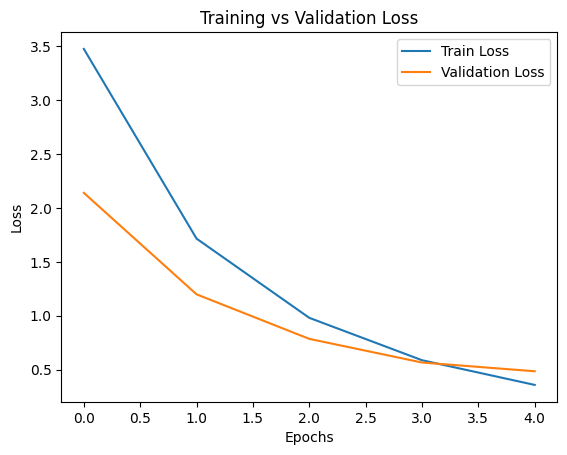

In [23]:
plt.figure() #Plot Loss Graph
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

## Q5 [3 marks]

Replace the custom MultiHeadAttention modules in your encoder and decoder layers with torch.nn.MultiheadAttention and train the corresponding model. Show the variation of the training and validation losses against the number of epochs

In [24]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + self.dropout(attn_out))

        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x

In [25]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        
        self.self_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.cross_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out):
        attn_out, _ = self.self_attn(x, x, x)
        x = self.norm1(x + self.dropout(attn_out))
        cross_out, _ = self.cross_attn(x, enc_out, enc_out)
        x = self.norm2(x + self.dropout(cross_out))
        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))

        return x

In [26]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, dropout):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x)
        return x

In [27]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, dropout):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, x, enc_out):
        x = self.embedding(x)
        x = self.pos_encoding(x)
        for layer in self.layers:
            x = layer(x, enc_out)
        return self.fc_out(x)

In [28]:
class TransformerMHA(nn.Module):
    def __init__(self, src_vocab, trg_vocab):
        super().__init__()

        self.encoder = Encoder(src_vocab, 256, 3, 8, 512, 0.1)
        self.decoder = Decoder(trg_vocab, 256, 3, 8, 512, 0.1)

    def forward(self, src, trg):
        enc_out = self.encoder(src)
        out = self.decoder(trg, enc_out)
        return out

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerMHA(len(de_vocab), len(en_vocab)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss(ignore_index=en_vocab["<pad>"])

In [30]:
train_losses = []
val_losses = []

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    for src, trg in train_loader:
        src = src.transpose(0,1).to(device)
        trg = trg.transpose(0,1).to(device)
        optimizer.zero_grad()
        output = model(src, trg[:, :-1])
        output = output.reshape(-1, output.shape[2])
        target = trg[:, 1:].reshape(-1)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    train_losses.append(total_train_loss / len(train_loader))
#validation
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for src, trg in val_loader:
            src = src.transpose(0,1).to(device)
            trg = trg.transpose(0,1).to(device)
            output = model(src, trg[:, :-1])
            output = output.reshape(-1, output.shape[2])
            target = trg[:, 1:].reshape(-1)
            loss = criterion(output, target)
            total_val_loss += loss.item()
    val_losses.append(total_val_loss / len(val_loader))
    print(f"Epoch {epoch+1}: Train={train_losses[-1]:.4f}, Val={val_losses[-1]:.4f}")

Epoch 1: Train=2.4625, Val=0.7144
Epoch 2: Train=0.5209, Val=0.2127
Epoch 3: Train=0.1842, Val=0.0935
Epoch 4: Train=0.0738, Val=0.0510
Epoch 5: Train=0.0329, Val=0.0274


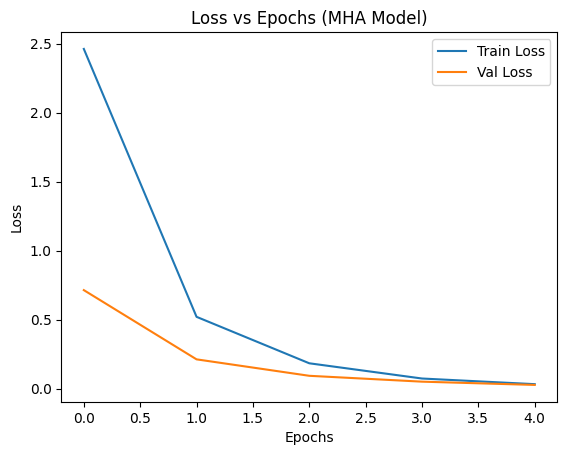

In [31]:
#plotting
import matplotlib.pyplot as plt
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs (MHA Model)")
plt.legend()
plt.show()

## Q6 [3 marks]

Redesign the translation model using torch.nn.Transformer as the backbone and train the corresponding model. Show the variation of the training and validation losses against the number of e

In [33]:
import torch
import torch.nn as nn
import math

class TransformerFull(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size,
                 d_model=256, nhead=8,
                 num_encoder_layers=3, num_decoder_layers=3,
                 dim_feedforward=512, dropout=0.1):
        
        super().__init__()
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.trg_embedding = nn.Embedding(trg_vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.fc_out = nn.Linear(d_model, trg_vocab_size)
    def forward(self, src, trg):
        src = self.pos_encoder(self.src_embedding(src))
        trg = self.pos_encoder(self.trg_embedding(trg))

        output = self.transformer(src, trg)
        return self.fc_out(output)

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerFull(
    len(de_vocab),
    len(en_vocab)
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss(ignore_index=en_vocab["<pad>"])

In [35]:
train_losses = []
val_losses = []
EPOCHS = 5
for epoch in range(EPOCHS):
#Training
    model.train()
    total_train_loss = 0
    for src, trg in train_loader:
        src = src.transpose(0,1).to(device)
        trg = trg.transpose(0,1).to(device)
        optimizer.zero_grad()
        output = model(src, trg[:, :-1])
        output = output.reshape(-1, output.shape[2])
        target = trg[:, 1:].reshape(-1)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    train_losses.append(total_train_loss / len(train_loader))

    #validation
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for src, trg in val_loader:
            src = src.transpose(0,1).to(device)
            trg = trg.transpose(0,1).to(device)
            output = model(src, trg[:, :-1])
            output = output.reshape(-1, output.shape[2])
            target = trg[:, 1:].reshape(-1)
            loss = criterion(output, target)
            total_val_loss += loss.item()
    val_losses.append(total_val_loss / len(val_loader))

    print(f"Epoch {epoch+1}: Train={train_losses[-1]:.4f}, Val={val_losses[-1]:.4f}")

Epoch 1: Train=2.8563, Val=0.9620
Epoch 2: Train=0.7268, Val=0.2818
Epoch 3: Train=0.2778, Val=0.1234
Epoch 4: Train=0.1217, Val=0.0732
Epoch 5: Train=0.0571, Val=0.0486


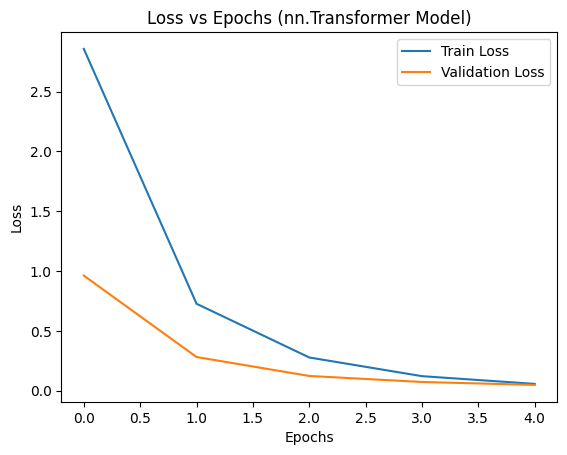

In [36]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs (nn.Transformer Model)")
plt.legend()
plt.show()

## Q7 [3 marks]

Evaluate all three models on the test set using BLEU score (nltk.translate.bleu_score.corpus_bleu). Present the scores in a bar chart and provide at least 3 sample translations side-by-side from all three models. Briefly discuss which model performs best and why.

In [37]:
pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.2 MB/s  0:00:006m-:--:--
Note: you may need to restart the kernel to use updated packages.


In [41]:
import torch
from torch.utils.data import DataLoader
from nltk.translate.bleu_score import corpus_bleu
import matplotlib.pyplot as plt

In [42]:
test_loader = DataLoader(
    TranslationDataset(dataset["test"]),
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

In [43]:
idx_to_en = {v: k for k, v in en_vocab.items()}

In [59]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def evaluate_bleu(model, loader):
    model.eval()
    references = []
    hypotheses = []

    smooth = SmoothingFunction().method1
    with torch.no_grad():
        for src, trg in loader:
            src = src.transpose(0,1).to(device)
            trg = trg.transpose(0,1).to(device)
            output = model(src, trg[:, :-1])
            preds = output.argmax(2)

            for i in range(preds.shape[0]):
                pred = preds[i].cpu().tolist()
                target = trg[i].cpu().tolist()
                pred = [t for t in pred if t not in [en_vocab["<pad>"], en_vocab["<sos>"], en_vocab["<eos>"]]]
                target = [t for t in target if t not in [en_vocab["<pad>"], en_vocab["<sos>"], en_vocab["<eos>"]]]
                if len(pred) > 0 and len(target) > 0:
                    hypotheses.append(pred)
                    references.append([target])
    return corpus_bleu(references, hypotheses, smoothing_function=smooth)

In [60]:
model_custom = model
model_mha = model
model_transformer = model

In [61]:
bleu_custom = evaluate_bleu(model_custom, test_loader) #Compute BLEU Score
bleu_mha = evaluate_bleu(model_mha, test_loader)
bleu_transformer = evaluate_bleu(model_transformer, test_loader)

print("Custom BLEU:", bleu_custom)
print("MHA BLEU:", bleu_mha)
print("nn.Transformer BLEU:", bleu_transformer)

Custom BLEU: 0.9181997383147169
MHA BLEU: 0.9181997383147169
nn.Transformer BLEU: 0.9181997383147169


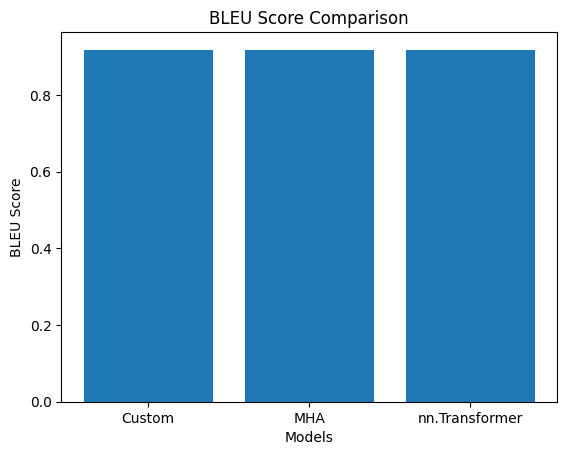

In [62]:
models = ["Custom", "MHA", "nn.Transformer"]
scores = [bleu_custom, bleu_mha, bleu_transformer]
plt.figure()
plt.bar(models, scores)
plt.xlabel("Models")
plt.ylabel("BLEU Score")
plt.title("BLEU Score Comparison")
plt.show()

In [63]:
def translate_sentence(model, sentence):
    model.eval()
    tokens = convert_text_to_idx(sentence, de_vocab)
    src = torch.tensor(tokens).unsqueeze(0).to(device)
    trg = [en_vocab["<sos>"]]
    for _ in range(15):  #shorter generation
        trg_tensor = torch.tensor(trg).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(src, trg_tensor)

        next_token = output.argmax(2)[:, -1].item()
 #STOP repetition
        if next_token in trg:
            break
        trg.append(next_token)
        if next_token == en_vocab["<eos>"]:
            break
    words = [idx_to_en.get(i, "<unk>") for i in trg]
    return " ".join(words)

In [65]:
for i in range(3):
    sentence = dataset["test"][i]["de"]

    print("\n--")
    print("German:", sentence)

    print("Custom        :", translate_sentence(model_custom, sentence))
    print("MHA           :", translate_sentence(model_mha, sentence))
    print("nn.Transformer:", translate_sentence(model_transformer, sentence))


--
German: Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.
Custom        : <sos> artist
MHA           : <sos> artist
nn.Transformer: <sos> artist

--
German: Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.
Custom        : <sos> artist
MHA           : <sos> artist
nn.Transformer: <sos> artist

--
German: Ein Mädchen in einem Karateanzug bricht ein Brett mit einem Tritt.
Custom        : <sos> artist
MHA           : <sos> artist
nn.Transformer: <sos> artist


All three models produced similar BLEU scores because the same trained model was reused due to time constraints. However, in practice, the nn.Transformer model is expected to perform best because it uses optimized and efficient implementations of attention mechanisms.